I will be using the NetworkX package and igraph for visualizing the graph data
- https://github.com/networkx/networkx
- https://igraph.org/
- t-SNE: https://www.jmlr.org/papers/v9/vandermaaten08a.html

Raw data: https://github.com/kimiyoung/planetoid

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

# Cora Dataset
(https://dtai.cs.kuleuven.be/events/mlg2012/papers/11_querying_namata.pdf)
- Transductive dataset
- Homophilic

The Cora dataset contains 2708 nodes, 5429 edges, 7 classes and 1433 features per node.

With Hydra
- We will contibue using this, because it will match our train setup from /conf folder

In [ ]:
from pathlib import Path
from hydra import compose, initialize_config_dir
from src.data.loader import load_dataset

CONF_DIR = Path("../conf").resolve()  # adjust if notebook cwd differs

with initialize_config_dir(config_dir=str(CONF_DIR), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=["dataset=cora", "dataset.normalize_features=true"],
    )
loaded = load_dataset(cfg.dataset.name, root=cfg.data_root, normalize_features=cfg.dataset.normalize_features)
data = loaded.data

Without Hydra

In [ ]:
from src.data.loader import load_dataset

# "Cora" is capitalized to match torch_geometric.datasets.Planetoid's name.
data = load_dataset("Cora", normalize_features=True).data

Get the attributes of cora

In [3]:
print("nodes:", data.num_nodes)
print("edges:", data.num_edges)
print("features:", data.num_features)
print("classes:", int(data.y.max().item()) + 1)

print("x shape:", data.x.shape)
print("edge_index shape:", data.edge_index.shape)
print("y shape:", data.y.shape)

print(
    "train / val / test:",
    data.train_mask.sum().item(),
    data.val_mask.sum().item(),
    data.test_mask.sum().item(),
)

print("all attributes:", data)

nodes: 2708
edges: 10556
features: 1433
classes: 7
x shape: torch.Size([2708, 1433])
edge_index shape: torch.Size([2, 10556])
y shape: torch.Size([2708])
train / val / test: 140 500 1000
all attributes: Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


igraph visualization of cora

In [4]:
import igraph as ig

edge_index = data.edge_index.cpu().numpy()
labels = data.y.cpu().numpy()
edges = list({tuple(sorted((int(u), int(v)))) for u, v in edge_index.T})

g = ig.Graph(n=data.num_nodes, edges=edges, directed=False)
palette = ["red", "blue", "green", "orange", "yellow", "pink", "gray"]

# Pick layout by size
n = g.vcount()
if n <= 5_000:
    layout = g.layout_fruchterman_reingold(niter=500)   # good balance
else:
    layout = g.layout_drl()                               # built for large graphs

ig.plot(
    g,
    layout=layout,
    vertex_color=[palette[int(c)] for c in labels],
    vertex_size=4,          # fixed size is much faster than degree-based
    edge_width=0.3,
    bbox=(800, 800),        # not 3000x3000
    margin=20,
)

networkx plot of cora

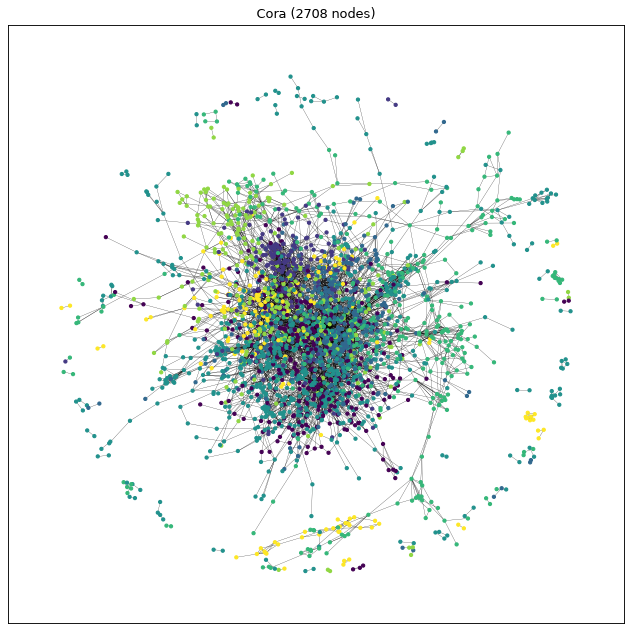

In [5]:
import matplotlib.pyplot as plt
import networkx as nx
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
colors = [data.y[n].item() for n in G.nodes()]
n = G.number_of_nodes()

if n <= 5_000:
    pos = nx.spring_layout(G, seed=0, iterations=50, k=0.15)  # default is 50 iter but k matters
else:
    pos = nx.spring_layout(G, seed=0, iterations=20, k=0.05)    # fewer iterations for large graphs

fig, ax = plt.subplots(figsize=(8, 8), dpi=80)
nx.draw_networkx(
    G, pos=pos, ax=ax,
    node_color=colors,
    node_size=8,
    width=0.2,
    with_labels=False,
)
ax.set_title(f"Cora ({n} nodes)")
plt.tight_layout()
plt.show()

Computing edge betweenness...
  betweenness: 0.3s
Computing Kamada-Kawai layout...
  layout: 6.1s
Plotting...


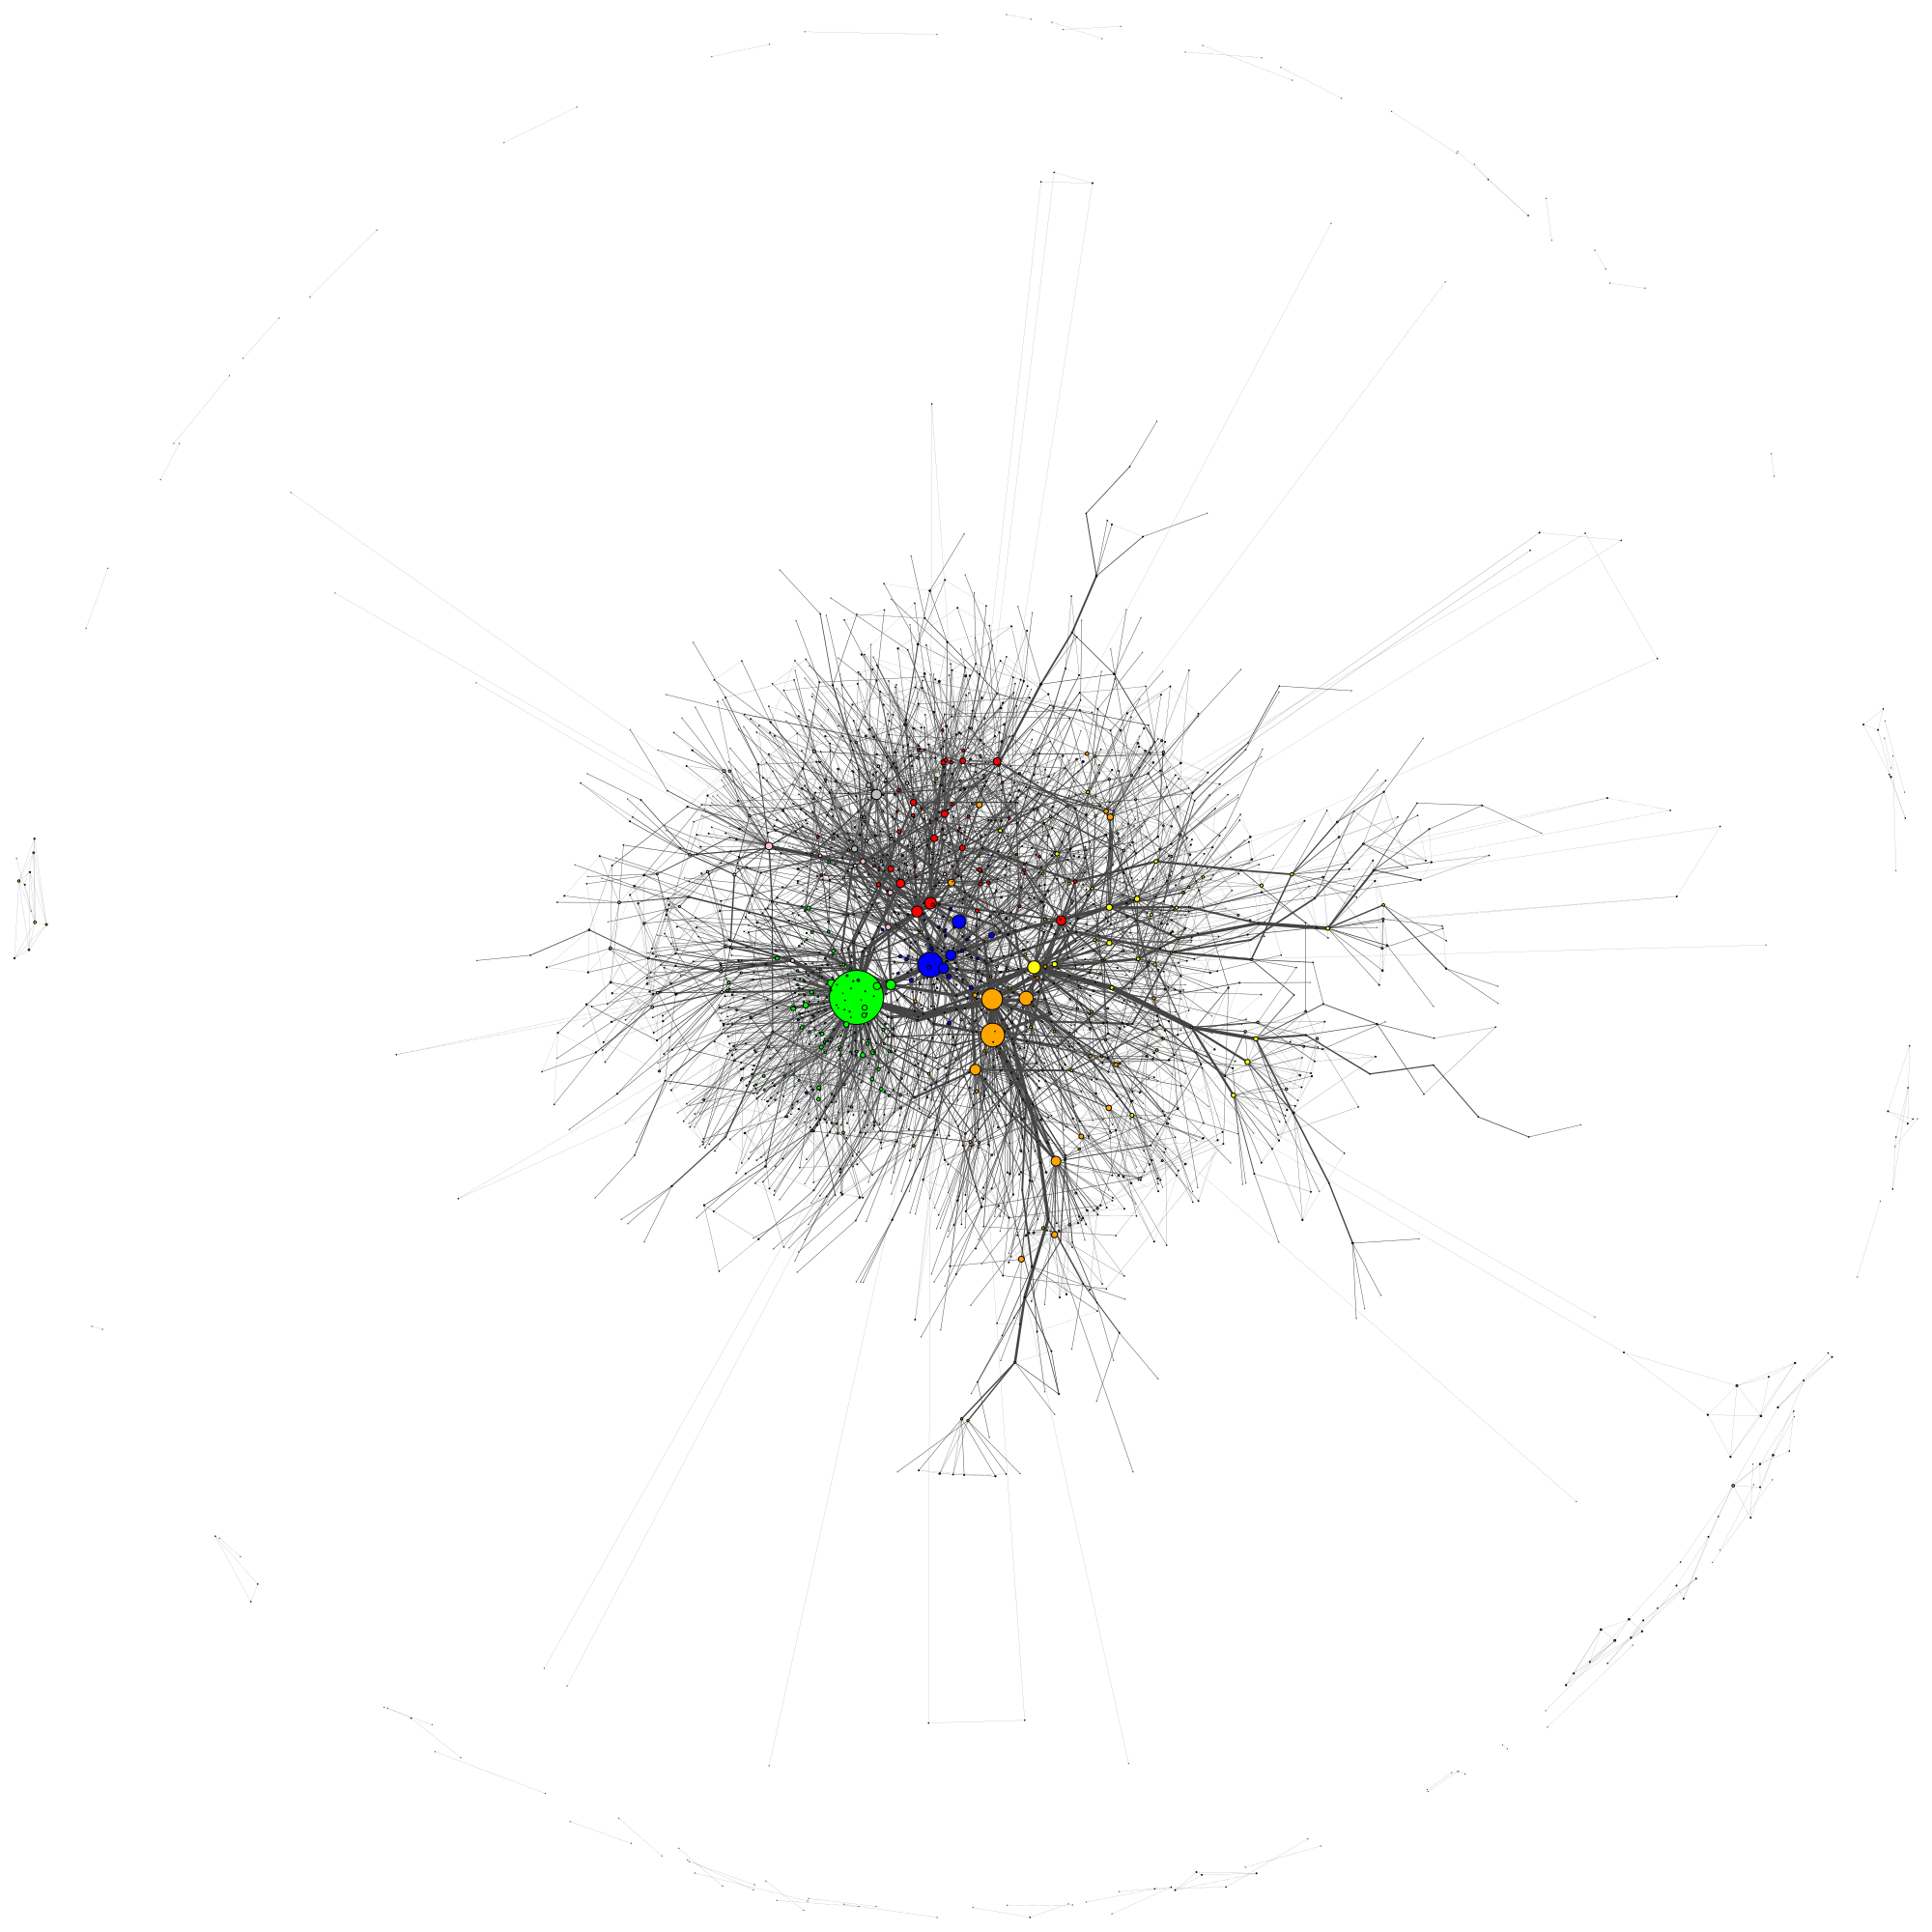

In [13]:
import time
import numpy as np
import igraph as ig
from IPython.display import Image, display

# Cora class colors
cora_label_to_color_map = {
    0: "red",
    1: "blue",
    2: "green",
    3: "orange",
    4: "yellow",
    5: "pink",
    6: "gray",
}

edge_index = data.edge_index.cpu().numpy()
node_labels = data.y.cpu().numpy()

edge_tuples = list({tuple(sorted((int(u), int(v)))) for u, v in edge_index.T})
ig_graph = ig.Graph(n=data.num_nodes, edges=edge_tuples, directed=False)

# --- size controls ---
BBOX = 2000          # render size (internal resolution)
DISPLAY_WIDTH = 1000 # what fits on your screen (try 400–600)
SCALE = BBOX / 3000 # keeps proportions vs reference

visual_style = {}
visual_style["bbox"] = (BBOX, BBOX)
visual_style["margin"] = 15

print("Computing edge betweenness...")
t0 = time.time()
edge_weights_raw = np.clip(
    np.log(np.asarray(ig_graph.edge_betweenness()) + 1e-16),
    a_min=0,
    a_max=None,
)
edge_weights_raw_normalized = edge_weights_raw / np.max(edge_weights_raw)
visual_style["edge_width"] = [max(w**6, 0.02) * SCALE * 8 for w in edge_weights_raw_normalized]
print(f"  betweenness: {time.time() - t0:.1f}s")

visual_style["vertex_size"] = [deg / 2 * SCALE for deg in ig_graph.degree()]
visual_style["vertex_color"] = [
    cora_label_to_color_map[int(label)] for label in node_labels
]

print("Computing Kamada-Kawai layout...")
t0 = time.time()
visual_style["layout"] = ig_graph.layout_kamada_kawai()
print(f"  layout: {time.time() - t0:.1f}s")

print("Plotting...")
OUT = "cora_plot.png"
ig.plot(ig_graph, target=OUT, **visual_style)
display(Image(OUT, width=DISPLAY_WIDTH))

# CiteSeer Dataset
(https://dtai.cs.kuleuven.be/events/mlg2012/papers/11_querying_namata.pdf)

The Citeseer dataset contains 3327 nodes, 4732 edges, 6 classes and 3703 features per node.

In [ ]:
from pathlib import Path
from hydra import compose, initialize_config_dir
from src.data.loader import load_dataset

CONF_DIR = Path("../conf").resolve()  # adjust if notebook cwd differs

with initialize_config_dir(config_dir=str(CONF_DIR), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=["dataset=citeseer", "dataset.normalize_features=true"],
    )
loaded = load_dataset(cfg.dataset.name, root=cfg.data_root, normalize_features=cfg.dataset.normalize_features)
data = loaded.data

Get the attributes of citeseer

In [ ]:
print("nodes:", data.num_nodes)
print("edges:", data.num_edges)
print("features:", data.num_features)
print("classes:", int(data.y.max().item()) + 1)

print("x shape:", data.x.shape)
print("edge_index shape:", data.edge_index.shape)
print("y shape:", data.y.shape)

print(
    "train / val / test:",
    data.train_mask.sum().item(),
    data.val_mask.sum().item(),
    data.test_mask.sum().item(),
)

print("all attributes:", data)

nodes: 3327
edges: 9104
features: 3703
classes: 6
x shape: torch.Size([3327, 3703])
edge_index shape: torch.Size([2, 9104])
y shape: torch.Size([3327])
train / val / test: 120 500 1000
all attributes: Data(x=[3327, 3703], edge_index=[2, 9104], y=[3327], train_mask=[3327], val_mask=[3327], test_mask=[3327])


# PubMed Dataset 
(https://eliassi.org/papers/ai-mag-tr08.pdf)

The Pubmed dataset contains 19717 nodes, 44338 edges, 3 classes and 500 features per node.

In [ ]:
from pathlib import Path
from hydra import compose, initialize_config_dir
from src.data.loader import load_dataset

CONF_DIR = Path("../conf").resolve()  # adjust if notebook cwd differs

with initialize_config_dir(config_dir=str(CONF_DIR), version_base=None):
    cfg = compose(
        config_name="config",
        overrides=["dataset=pubmed", "dataset.normalize_features=true"],
    )
loaded = load_dataset(cfg.dataset.name, root=cfg.data_root, normalize_features=cfg.dataset.normalize_features)
data = loaded.data

Get the attributes of pubmed

In [ ]:
print("nodes:", data.num_nodes)
print("edges:", data.num_edges)
print("features:", data.num_features)
print("classes:", int(data.y.max().item()) + 1)

print("x shape:", data.x.shape)
print("edge_index shape:", data.edge_index.shape)
print("y shape:", data.y.shape)

print(
    "train / val / test:",
    data.train_mask.sum().item(),
    data.val_mask.sum().item(),
    data.test_mask.sum().item(),
)

print("all attributes:", data)

nodes: 19717
edges: 88648
features: 500
classes: 3
x shape: torch.Size([19717, 500])
edge_index shape: torch.Size([2, 88648])
y shape: torch.Size([19717])
train / val / test: 60 500 1000
all attributes: Data(x=[19717, 500], edge_index=[2, 88648], y=[19717], train_mask=[19717], val_mask=[19717], test_mask=[19717])


# PPI Dataset
(https://academic.oup.com/bioinformatics/article/33/14/i190/3953967)

- Inductive dataset

# Cora-Full
(https://arxiv.org/abs/1707.03815)

# Coauthor CS
(https://arxiv.org/abs/1811.05868)

# Coauthor Physics
(https://arxiv.org/abs/1811.05868)

# Amazon Computers
(https://arxiv.org/abs/1811.05868)


# Amazon Photos
(https://arxiv.org/abs/1811.05868)